In [71]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

In [ ]:
data_dir = "./balanced_waste_images"
img_size = (224,224)
batch_size = 32
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = img_size,
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = img_size,
    batch_size = batch_size
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [73]:
data_augementation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [74]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [75]:
base_model = tf.keras.applications.MobileNet(
    input_shape = (224,224,3),
    include_top = False,
    weights = "imagenet"
)
base_model.trainable = False

In [76]:
num_classes = 4
inputs = keras.Input(shape = (224,224,3))
x = data_augementation(inputs)
x = preprocess_input(x)
x = base_model(x,training = False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes,activation= "softmax")(x)
model = keras.Model(inputs,outputs)

In [77]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [78]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 25
)

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 190ms/step - accuracy: 0.3527 - loss: 1.6597 - val_accuracy: 0.8031 - val_loss: 0.5653
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.7006 - loss: 0.7535 - val_accuracy: 0.8719 - val_loss: 0.3594
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.7937 - loss: 0.5350 - val_accuracy: 0.9000 - val_loss: 0.2805
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - accuracy: 0.8239 - loss: 0.4552 - val_accuracy: 0.9062 - val_loss: 0.2542
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.8501 - loss: 0.3776 - val_accuracy: 0.9187 - val_loss: 0.2354
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.8798 - loss: 0.3209 - val_accuracy: 0.9219 - val_loss: 0.2212
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.8606 - loss: 0.3590 - val_accuracy: 0.9156 - val_loss: 0.2190
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.8809 - loss: 0.3190 - val_accuracy: 0

In [79]:
from enum import Flag
base_model.trainable = True
for layer in base_model.layers[:-30]:
  layer.trainable = False
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-5),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
history_fine = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.8527 - loss: 0.3782 - val_accuracy: 0.9531 - val_loss: 0.1465
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 165ms/step - accuracy: 0.8932 - loss: 0.3289 - val_accuracy: 0.9469 - val_loss: 0.1559
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.8916 - loss: 0.3055 - val_accuracy: 0.9531 - val_loss: 0.1598
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.9145 - loss: 0.2225 - val_accuracy: 0.9406 - val_loss: 0.1651
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.9043 - loss: 0.2686 - val_accuracy: 0.9406 - val_loss: 0.1666
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.9359 - loss: 0.2025 - val_accuracy: 0.9406 - val_loss: 0.1641
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.9325 - loss: 0.1692 - val_accuracy: 0.9406 - val_loss: 0.1593
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.9250 - loss: 0.1881 - val_accuracy: 

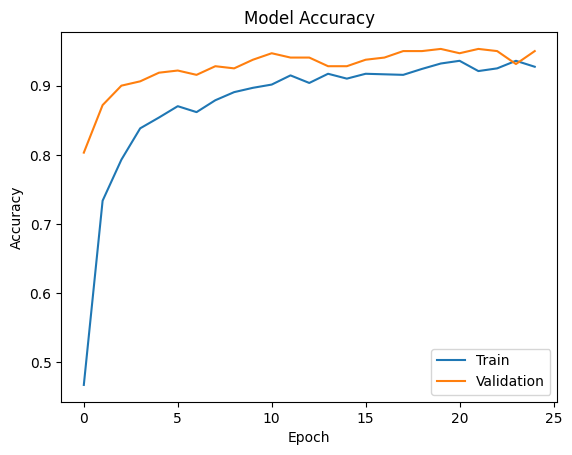

In [80]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])
plt.show()

In [92]:
model.save("waste_classifier_model.keras")

In [82]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds), axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step
[[17 15 17 21]
 [23 28 20 21]
 [21 25 17 15]
 [19 23 22 16]]
              precision    recall  f1-score   support

           0       0.21      0.24      0.23        70
           1       0.31      0.30      0.31        92
           2       0.22      0.22      0.22        78
           3       0.22      0.20      0.21        80

    accuracy                           0.24       320
   macro avg       0.24      0.24      0.24       320
weighted avg       0.24      0.24      0.24       320



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step


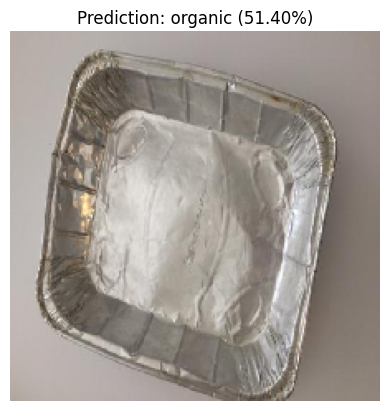

In [83]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load mode

# Your class labels (MUST match training folder order)
class_names = ['metal', 'organic', 'paper', 'plastic']

# Load PNG image
img_path = "/content/metal5.jpg"   # your PNG file
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Expand dimensions (model expects batch)
img_array = np.expand_dims(img_array, axis=0)

# Apply MobileNetV2 preprocessing
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)

predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)

# Show result
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

In [84]:
for i, prob in enumerate(predictions[0]):
    print(f"{class_names[i]}: {prob*100:.2f}%")

metal: 6.42%
organic: 51.40%
paper: 38.13%
plastic: 4.06%


In [85]:
print(train_ds.class_names)

['metal', 'organic', 'paper', 'plastic']


In [86]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


In [87]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.9455 - loss: 0.1359
Validation Accuracy: 0.9375


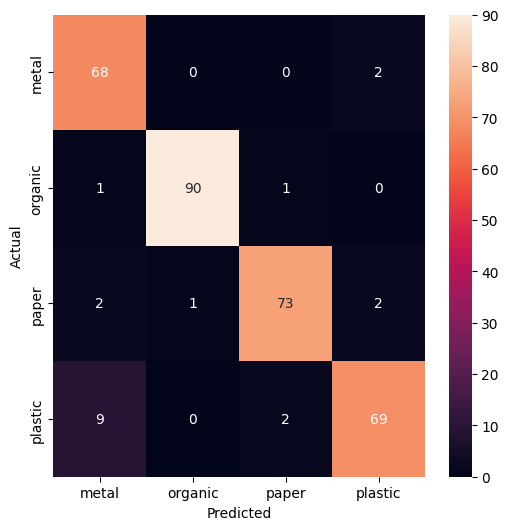

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=val_ds.class_names,
            yticklabels=val_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [89]:
loss, accuracy = model.evaluate(train_ds)
print("Training Accuracy:", accuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9769 - loss: 0.0667
Training Accuracy: 0.9765625


In [90]:
import numpy as np

y_true_train = []
y_pred_train = []

for images, labels in train_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_train.extend(labels.numpy())
    y_pred_train.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

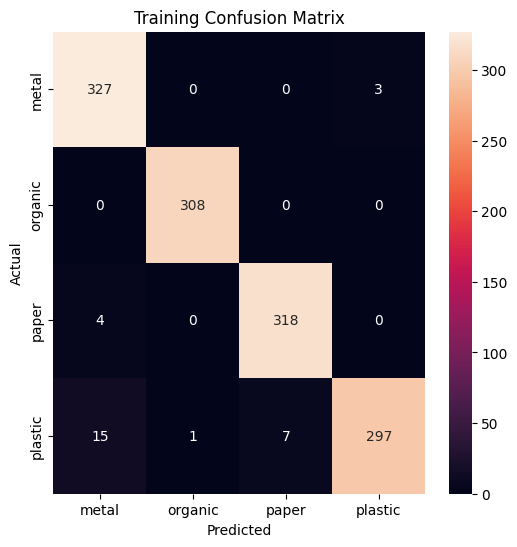

              precision    recall  f1-score   support

       metal       0.95      0.99      0.97       330
     organic       1.00      1.00      1.00       308
       paper       0.98      0.99      0.98       322
     plastic       0.99      0.93      0.96       320

    accuracy                           0.98      1280
   macro avg       0.98      0.98      0.98      1280
weighted avg       0.98      0.98      0.98      1280



In [91]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm_train = confusion_matrix(y_true_train, y_pred_train)

plt.figure(figsize=(6,6))
sns.heatmap(cm_train, annot=True, fmt="d",
            xticklabels=train_ds.class_names,
            yticklabels=train_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Training Confusion Matrix")
plt.show()

print(classification_report(
    y_true_train,
    y_pred_train,
    target_names=train_ds.class_names
))